In [61]:
from typing import Dict
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from typing import Callable
import time
from tensorflow.keras.saving import register_keras_serializable
print(tf.keras.__version__)
u0 = 50
theta = np.deg2rad(45)
g = 9.8

#Initial conditions
y0 = 0
yf = 0
v0 = 0
vf = 0

print((2*u0*np.sin(theta))/g)

t = np.round(np.linspace(0, 7, 64), 1)
y = (u0 * np.sin(theta) * t) - ((0.5 * g) * t ** 2)


3.9.0
7.215375318230075


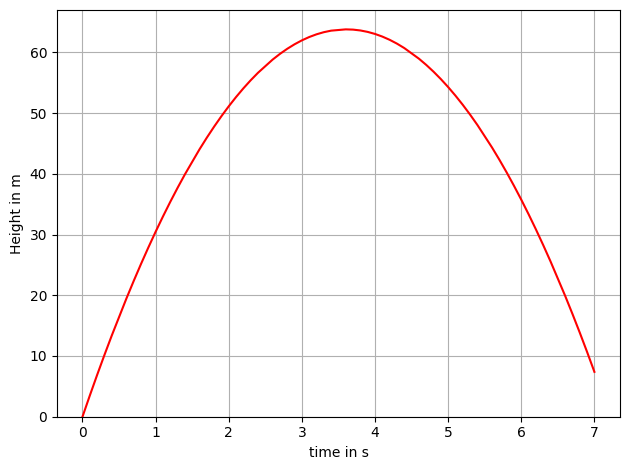

In [62]:
plt.plot(t, y, color='red')
plt.xlabel('time in s')
plt.ylabel('Height in m')
plt.grid(True)
plt.ylim(ymin=0)
plt.tight_layout()
plt.show()

In [63]:
def generate_data() -> tf.Tensor:
    t = np.round(np.linspace(0, 7, 64), 1)
    return tf.convert_to_tensor(t, dtype=tf.float32)

In [64]:
@register_keras_serializable()
class PhysicsNN(tf.keras.Model):
    def __init__(self, layer_sizes: list, activation: Callable = tf.nn.tanh, **kwargs):
        super().__init__(**kwargs)
        #Initial conditions
        self.y0 = 0
        self.v0 = u0
        self.theta = np.deg2rad(45)
        #Hidden layers
        self.hidden_layers = [tf.keras.layers.Dense(size) for size in layer_sizes]
        #Output layers
        self.output_layer = tf.keras.layers.Dense(1)
        #Activation function
        self.activation = activation
        
    def call(self, t: tf.Tensor) -> tf.Tensor:
        x = t
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        out = self.output_layer(x)
        return self.y0 + self.v0 * t * np.sin(theta)  + (t**2)*out ## enforcing intital conditions in the network

    @classmethod
    def from_config(cls, config: Dict[str, any]) -> 'PhysicsNNs':
        layer_sizes = config.pop('layer_sizes', [64])
        return cls(layer_sizes, **config)

In [65]:
#Function for calculating derivative.
def cal_derivative(model: PhysicsNN, t: tf.Tensor, order: int = 1) -> tf.Tensor:
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        y = model(t)
        dy = y
        for i in range(order):
            dy = tape.gradient(dy, t)
    return dy

In [66]:
#Function to calculate the ode residual
def physics_equation(model: PhysicsNN, t: tf.Tensor) -> tf.Tensor:
    global g
    y = model(t)
    d2y_dt2 = cal_derivative(model, t, order=2)
    ode = d2y_dt2 + g
    return ode

In [67]:
#Function to calcualte the loss
def loss_function(model: PhysicsNN, t: tf.Tensor) -> tf.Tensor:
    lmb_phy = 5
    mean_squared_error_phy = tf.reduce_mean(physics_equation(model, t)**2)
    return lmb_phy * mean_squared_error_phy

In [68]:
from IPython.display import clear_output
loss_list = []
def train(model: PhysicsNN) -> PhysicsNN:

    start = time.time()
    epochs = 1500
    inputs = tf.expand_dims(generate_data(), axis=-1)

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            loss = loss_function(model, inputs)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        loss_list.append(loss.numpy())
        if epoch % 100 == 0 or epoch == epochs - 1:
            clear_output(wait=True)

            fig, ax = plt.subplots(1, 2, figsize=(15, 5))

            pred_y = model(inputs)
            ax[0].plot(t, y, color='yellow')
            ax[0].plot(t, pred_y.numpy(), color = 'blue', alpha = 0.5, ls='--')
            ax[0].set_xlabel('time in s')
            ax[0].set_ylabel('Height in m')
            ax[0].grid(True)

            ax[1].plot(loss_list, color = 'black')
            ax[1].set_xlabel('Epochs')
            ax[1].set_ylabel('Loss')
            ax[1].set_xlim(0, epochs)
            ax[1].grid(True)
            
            plt.show()
            
            cost = time.time() - start
            print(f"Time take: {cost}, Epoch: {epoch}/{epochs} Loss: {loss}")
    return model

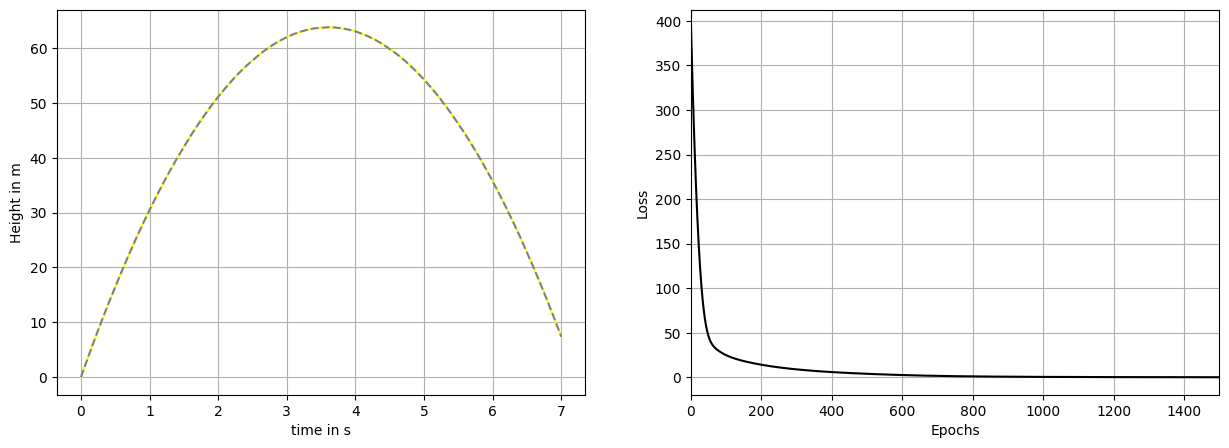

Time take: 18.80193042755127, Epoch: 1499/1500 Loss: 0.1110399141907692


In [69]:
model = PhysicsNN(layer_sizes=[64])
model.summary()
model = train(model)

In [70]:
from scipy.optimize import minimize
lmb_loss = 5
#model1 = tf.keras.models.load_model('navier_stokes_incompressible_steady_state_lid_drive_cavity_2d.keras', safe_mode=False)
iteration = [0]
# Helper: flatten model weights to 1D numpy array
def get_weights_vector(model):
    weights = model.get_weights()
    return np.concatenate([w.flatten() for w in weights])

# Helper: set model weights from 1D numpy array
def set_weights_vector(model, weights_vector):
    weights = model.get_weights()
    new_weights = []
    idx = 0
    for w in weights:
        shape = w.shape
        size = w.size
        new_w = weights_vector[idx:idx+size].reshape(shape)
        new_weights.append(new_w)
        idx += size
    model.set_weights(new_weights)

# Loss function wrapper for L-BFGS
def loss_and_grad(weights_vector):
    inputs = tf.expand_dims(generate_data(), axis=-1)
    set_weights_vector(model, weights_vector)

    with tf.GradientTape() as tape:
        # calculation of total loss
        loss = loss_function(model, inputs)
        total_loss = lmb_loss * loss

    grads = tape.gradient(total_loss, model.trainable_variables)
    # flatten gradients to 1D numpy array
    grads_vector = np.concatenate([g.numpy().flatten() for g in grads])
    if iteration[0] % 10 == 0:  # print every 10 steps
        print(f"L-BFGS iteration {iteration[0]}: total_loss = {total_loss.numpy():.6e}")
    iteration[0] += 1
    return total_loss.numpy().astype(np.float64), grads_vector.astype(np.float64)
    
# Run L-BFGS optimization
weights_init = get_weights_vector(model)

result = minimize(fun=loss_and_grad,
                  x0=weights_init,
                  jac=True,          # use gradient
                  method='L-BFGS-B',
                  options={'maxiter': 50000, 'maxcor': 50, 'maxfun': 50000, 'maxls': 50, 'ftol': 1.0 * np.finfo(float).eps})

# Set optimized weights back to model
set_weights_vector(model, result.x)
#model.save("navier_stokes_incompressible_steady_state_lid_drive_cavity_lbfgs.keras")

L-BFGS iteration 0: total_loss = 5.539820e-01
L-BFGS iteration 10: total_loss = 4.247606e-01
L-BFGS iteration 20: total_loss = 1.494800e-01
L-BFGS iteration 30: total_loss = 9.578975e-02
L-BFGS iteration 40: total_loss = 1.651404e-02
L-BFGS iteration 50: total_loss = 7.532224e-03
L-BFGS iteration 60: total_loss = 5.823645e-03
L-BFGS iteration 70: total_loss = 2.012786e-03
L-BFGS iteration 80: total_loss = 1.044860e-03
L-BFGS iteration 90: total_loss = 7.558881e-04
L-BFGS iteration 100: total_loss = 2.551023e-04
L-BFGS iteration 110: total_loss = 1.893054e-04
L-BFGS iteration 120: total_loss = 1.057399e-04
L-BFGS iteration 130: total_loss = 8.909461e-05
L-BFGS iteration 140: total_loss = 8.631092e-05


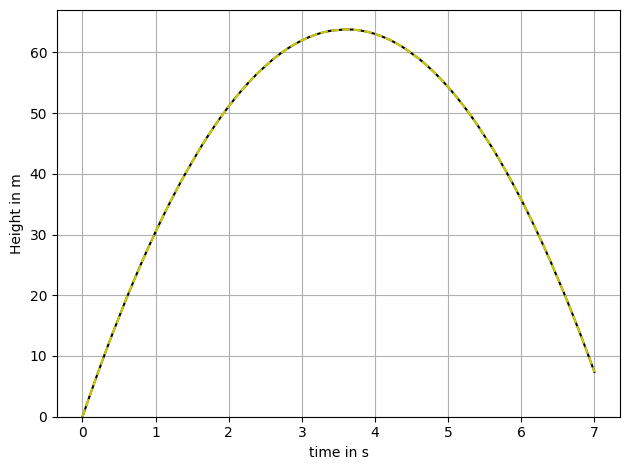

In [71]:
pred_y = model(tf.expand_dims(t, axis=-1))
plt.plot(t, y, color='black')
plt.plot(t, pred_y.numpy(), color='yellow', ls='--', alpha=0.8)
plt.xlabel('time in s')
plt.ylabel('Height in m')
plt.grid(True)
plt.ylim(ymin=0)
plt.tight_layout()
plt.show()

In [72]:
model.save("projectile_motion_2d_ode_PINN.keras")

In [73]:
# Example to load the model
inferencing_model = tf.keras.models.load_model('projectile_motion_2d_ode_PINN.keras', custom_objects={"PhysicsNN":PhysicsNN})